# 6D Pose Estimation

## Initialize


### Initial Setup

In [2]:
import os
import sys
import subprocess
import shutil
from pathlib import Path

REPO_URL = "https://github.com/luigiaceto/6D-pose-estimation.git"
REPO_BRANCH = "baseline-rgb-geometric-depth-v2"
GDRIVE_DATASET_URL = "https://drive.google.com/drive/folders/19ivHpaKm9dOrr12fzC8IDFczWRPFxho7"

EXEC_ENV = "unknown" 

def run_command(command, check=True):
    """Esegue comandi shell."""
    try:
        subprocess.run(command, shell=True, check=check)
    except subprocess.CalledProcessError as e:
        print(f"❌ Errore comando: {command}")
        raise e

def detect_environment():
    """Rileva l'ambiente."""
    if 'google.colab' in sys.modules:
        return 'colab'
    elif os.path.exists('/kaggle'):
        return 'kaggle'
    else:
        return 'local'

def download_and_setup_dataset_gdown(dest_root="datasets/linemod"):
    """
    Funzione Helper per scaricare dataset da GDrive (Usata da Colab e Local).
    """
    dest_path = Path(dest_root)
    
    # Se il dataset esiste già e non è vuoto, saltiamo
    if dest_path.exists() and any(dest_path.iterdir()):
        print("✅ Dataset già presente.")
        return

    print(f"📥 Downloading dataset to {dest_root}...")
    run_command("pip install -q gdown") # Assicura gdown
    
    os.makedirs(dest_path, exist_ok=True)
    # Salviamo la cwd per tornarci dopo
    original_cwd = os.getcwd()
    os.chdir(dest_path)
    
    try:
        # 1. Scarica
        run_command(f'gdown --folder "{GDRIVE_DATASET_URL}" --quiet')
        
        # 2. Gestione Zip
        if os.path.exists("Linemod_preprocessed.zip"):
            print("📦 Unzipping...")
            run_command("unzip -q Linemod_preprocessed.zip")
            run_command("rm Linemod_preprocessed.zip")
        
        # 3. Fix struttura cartelle (se gdown crea sottocartella)
        if os.path.exists("Linemod_preprocessed"):
            print("📂 Adjusting folder structure...")
            run_command("mv Linemod_preprocessed/* .")
            run_command("rmdir Linemod_preprocessed")
            
        print("✅ Dataset Download & Setup Complete.")
        
    except Exception as e:
        print(f"❌ Errore download dataset: {e}")
    finally:
        os.chdir(original_cwd)


# --- LOGICA KAGGLE ---
def setup_kaggle():
    print("🔧 Setup KAGGLE (Robust)...")
    
    # 1. Fix NumPy
    try:
        import numpy
        is_bad = numpy.__version__.startswith("2.")
    except ImportError:
        is_bad = True

    if is_bad:
        print("🚨 NumPy incompatibility detected. Fixing...")
        pkgs = ["numpy", "scipy", "numpy-quaternion", "opencv-python-headless"]
        subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y"] + pkgs, check=False)
        
        install_pkgs = [
            "numpy==1.26.4", "scipy==1.11.4", "scikit-learn==1.3.2",
            "opencv-python-headless<4.10.0", "numpy-quaternion", "ultralytics", "pyyaml", "tqdm"
        ]
        subprocess.run([sys.executable, "-m", "pip", "install"] + install_pkgs, check=True)
        
        print("\n🛑 STOP: RIAVVIA LA SESSIONE (Run > Restart Session) e riesegui.")
        return False

    # 2. Clone Repo
    os.chdir("/kaggle/working")
    if not os.path.exists("6D-pose-estimation"):
        run_command(f"git clone -q -b {REPO_BRANCH} {REPO_URL}")
    
    repo_path = "/kaggle/working/6D-pose-estimation"
    if repo_path not in sys.path: sys.path.insert(0, repo_path)
    os.chdir(repo_path)

    # 3. Copy Dataset (Kaggle Input -> Working)
    SRC = Path("/kaggle/input/linemod/Linemod_preprocessed") 
    DST = Path("datasets/linemod")
    if not DST.exists():
        print("📦 Copia dataset da Input (veloce)...")
        shutil.copytree(SRC, DST, dirs_exist_ok=True)
    
    os.environ["WANDB_MODE"] = "disabled"
    return True

# --- LOGICA COLAB (MODIFICATA: NO DRIVE) ---
def setup_colab():
    print("🔧 Setup COLAB (Direct Download)...")
    
    # 1. Clone Repo
    if not os.path.exists('/content/6D-pose-estimation'):
        run_command(f"git clone -b {REPO_BRANCH} {REPO_URL} /content/6D-pose-estimation")
    else:
        os.chdir('/content/6D-pose-estimation')
        run_command("git pull")
    
    os.chdir('/content/6D-pose-estimation')
    
    # 2. Install Dependencies
    print("📦 Installing requirements...")
    run_command("pip install -q -r requirements.txt")
    
    # 3. DOWNLOAD DATASET (Niente Drive, scarica in locale VM)
    download_and_setup_dataset_gdown(dest_root="datasets/linemod")
    
    # Creiamo cartella checkpoints se non esiste
    os.makedirs("checkpoints", exist_ok=True)
    
    return True

# --- LOGICA LOCALE ---
def setup_local():
    print("🔧 Setup LOCAL...")
    if os.path.exists("requirements.txt"):
        run_command("pip install -q -r requirements.txt")
    
    download_and_setup_dataset_gdown(dest_root="datasets/linemod")
    return True

# --- MAIN ---
EXEC_ENV = detect_environment()

if EXEC_ENV == 'kaggle':
    if not setup_kaggle():
        EXEC_ENV = "kaggle_needs_restart" # Flag speciale
elif EXEC_ENV == 'colab':
    setup_colab()
else:
    setup_local()

print(f"\n🌍 Environment: {EXEC_ENV}")
if EXEC_ENV != "kaggle_needs_restart":
    print(f"📂 CWD: {os.getcwd()}")
    print("✅ Setup Completato.")

🔧 Setup LOCAL...
✅ Dataset già presente.

🌍 Environment: local
📂 CWD: c:\Users\Davide\OneDrive\Documenti\Universita\Magistrale\Corsi\Advance machine learning\project\6D-pose-estimation
✅ Setup Completato.


Get working directory:

Handle imports

In [3]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='pydantic')

from torch.utils.data import DataLoader
from pathlib import Path

from utils.init import set_seed
from utils.init import set_device
from utils.data_exploration import get_camera_intrinsics

set_seed(42)

device = set_device()

if EXEC_ENV == "kaggle": 
    dataset_root = Path("/kaggle/working/6D-pose-estimation/datasets/linemod")
    yolo_path = Path("/kaggle/working/6D-pose-estimation/datasets/linemod/YOLO/datasets")
    checkpoint_best_yolo_path = Path("/kaggle/input/chekpoint") / "best_yolo_model.pt"
    checkpoint_best_pose_path = Path("/kaggle/input/chekpoint") / "best_pose_model.pt"
else:
    dataset_root = Path("datasets") / "linemod" / "DenseFusion" / "Linemod_preprocessed"
    yolo_path = Path("datasets") / "linemod" / "YOLO" / "datasets"
    checkpoint_best_yolo_path = Path("checkpoints") / "best_yolo_model.pt"
    checkpoint_best_pose_path = Path("checkpoints") / "best_pose_model.pt"

cam_k = get_camera_intrinsics(dataset_root)

### Dataset Preprocessing

Copy ground truth files to ```Linemod_preprocessed```:

In [4]:
from utils.data_exploration import get_class_names
from utils.preprocessing import copy_gt_file, change_02gt, quaternion_gt

folder_names = get_class_names(dataset_root)

In [5]:
copy_gt_file(dataset_root, folder_names)

Change ```02_gt.yml``` to take only one object:

In [6]:
change_02gt(str(dataset_root / "02_gt.yml"))

Add quaternion:

In [7]:
quaternion_gt(dataset_root)

### Data Exploration

Load an image to check if it's all ok:

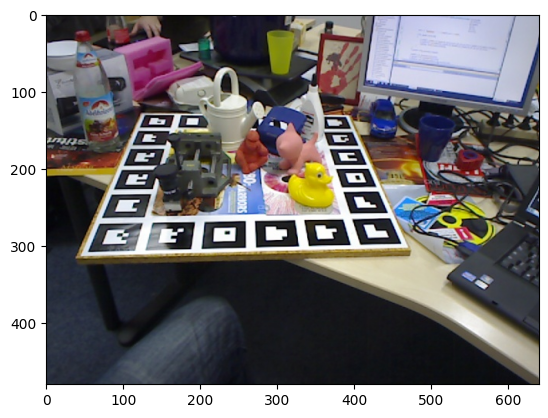

In [8]:
from utils.data_exploration import load_image

load_image(dataset_root, label=1, object=0)

### Define the Custom Dataset

In [9]:
from data.CustomDatasetPose import CustomDatasetPose

# Split 80% training / 20% testing
# Durante training useremo test set anche per validation
train_dataset = CustomDatasetPose(
    dataset_root=dataset_root,
    split="train",
    train_ratio=0.8,
    seed=42,
    cam_K=cam_k
)

test_dataset = CustomDatasetPose(
    dataset_root=dataset_root,
    split="test",
    train_ratio=0.8,
    seed=42,
    cam_K=cam_k
)

print(f"Training samples: {len(train_dataset)} (80%)")
print(f"Testing samples: {len(test_dataset)} (20%)")
print(f"Note: Test set verrà usato anche per validation durante training")

Training samples: 12640 (80%)
Testing samples: 3160 (20%)
Note: Test set verrà usato anche per validation durante training


### Visualize data

Visualize depth image:

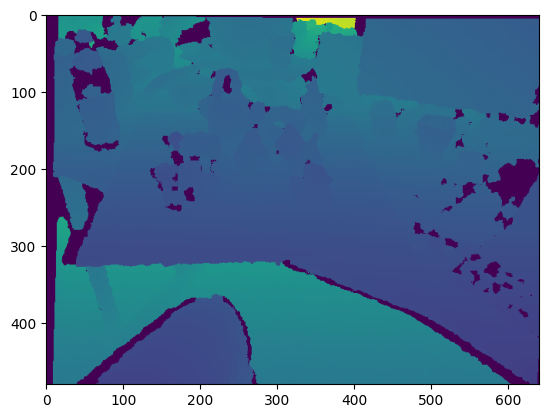

In [10]:
from utils.data_exploration import load_depth_image

folder = "01"
object_name = "0000"

img = load_depth_image(str(dataset_root / "data" / f"{folder}" / "depth" / f"{object_name}.png"))

Plot the patch of first object of the image, it reads from the ground truth file containing also multiple objects in one image:

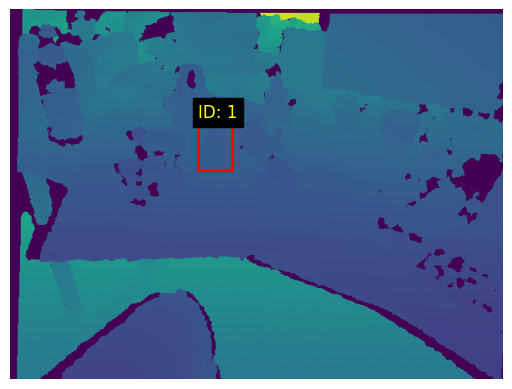

In [11]:
from utils.data_exploration import load_depth_patch

load_depth_patch(dataset_root, folder, object_name, img)

Get data loader:

In [12]:
# Dataloader per visualizzazione (batch piccolo)
viz_train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
viz_test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print(f"Visualization - Training loader: {len(viz_train_loader)}")
print(f"Visualization - Test loader: {len(viz_test_loader)}")

Visualization - Training loader: 3160
Visualization - Test loader: 790


Plot one batch of data:

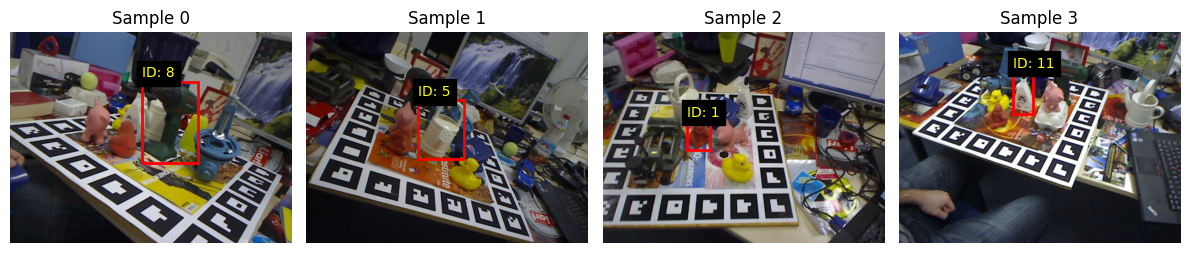

In [13]:
from utils.data_exploration import plot_batch_data

plot_batch_data(viz_train_loader, viz_test_loader, viz_test_loader)

## YOLO

### Data Preprocessing for YOLO

In [ ]:
train_samples = train_dataset.get_samples_id()
test_samples = test_dataset.get_samples_id()
validation_samples = test_samples  # Validation = Test (stesso 20%)

Create a new folder containing all the info for YOLO, we just need the rgb image and a text file with the label and bounding box.
The ```Linemod_preprocessed``` is not removed, as it contains info about translation and rotation that are needed for pose estimation, but not for YOLO object detection model.

Create YOLO yaml:

In [15]:
from utils.preprocessing import create_YOLO_yaml

number_classes, class_names = create_YOLO_yaml(folder_names)

While creating the folder structure, we have to change the class id by using the index in the array written in the ```data.yaml```:

In [16]:
# create a dictionary to have easily access to the index. Dato che usiamo un sottoinsieme
# di folder di LineMOD
index_dict = dict()
for index, elem in enumerate(class_names):
    index_dict[int(elem)] = index

Create the folders:

In [ ]:
from utils.preprocessing import create_dataset_YOLO

if (yolo_path / "train" / "images").exists() and len(list((yolo_path / "train" / "images").glob("*"))) > 0:
    print("Dataset YOLO già creato.")
    counter_df = None  
else:
    print("Creazione dataset YOLO in corso (può richiedere qualche minuto)...")
    counter_df = create_dataset_YOLO(
        number_classes, 
        train_samples, 
        validation_samples, 
        test_samples, 
        index_dict, 
        train_dataset
    )
    print("Dataset YOLO creato con successo!")

Dataset YOLO già creato, skip preprocessing.


Visualize dataset distribution:

In [18]:
from utils.data_exploration import load_dataset_distribution

if counter_df is not None:
    load_dataset_distribution(counter_df, index_dict, number_classes)
else:
    print("⏭️  Skipped: Dataset distribution già visualizzato in precedenza.")

⏭️  Skipped: Dataset distribution già visualizzato in precedenza.


In [ ]:
# YOLO Training Configuration
yolo_config = {
    "img_size": 640,
    "epochs": 20,
    "batch_size": 64
}

print(f"YOLO Configuration: {yolo_config}")

YOLO Configuration: {'img_size': 640, 'epochs': 20, 'batch_size': 64}


### Train YOLO

**[TRAINING ONLY]**

In [ ]:
from yolo_train import train_YOLO

train_YOLO(
    epochs=yolo_config["epochs"],
    batch_size=yolo_config["batch_size"],
    img_size=yolo_config["img_size"],
    device=device,
    yolo_dataset_path=yolo_path,
    checkpoint_dir="checkpoints"
)

### Evaluate YOLO

In [20]:
from yolo_evaluate import evaluate_YOLO

yolo_results = evaluate_YOLO(
    epochs=yolo_config["epochs"],
    batch_size=yolo_config["batch_size"],
    img_size=yolo_config["img_size"],
    device=device,
    yolo_dataset_path=yolo_path,
    model_path=checkpoint_best_yolo_path
)

YOLO11n summary (fused): 100 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 390.2171.6 MB/s, size: 463.7 KB)
val: Scanning C:\Users\Davide\OneDrive\Documenti\Universita\Magistrale\Corsi\Advance machine learning\project\6D-pose-estimation\datasets\linemod\YOLO\datasets\test\labels.cache... 3156 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3156/3156 1.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.0s/it 1:381.4sss
                   all       3156       3156      0.999      0.999      0.995      0.953
                    01        249        249          1      0.993      0.995      0.931
                    02        247        247      0.999          1      0.995      0.962
                    04        242        242          1          1      0.995      0.942
                    05        231        231      0.999          1      0.995      0.

### Visualize YOLO

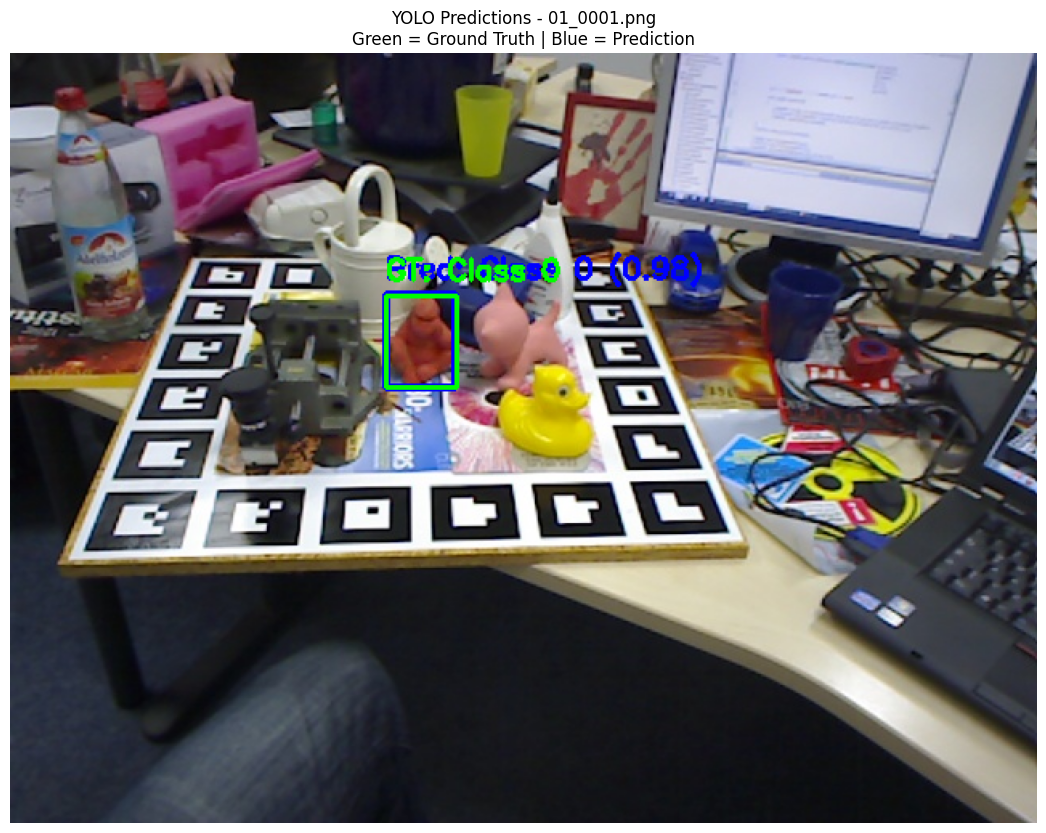


01_0001.png:
  Predictions: 1 boxes detected


In [21]:
import importlib
import yolo_visualize
importlib.reload(yolo_visualize)
from yolo_visualize import visualize_yolo_predictions

visualize_yolo_predictions(
    yolo_model_path=checkpoint_best_yolo_path,
    yolo_dataset_path=yolo_path,
    img_size=yolo_config["img_size"],
    conf_threshold=0.5,
    num_images=1
)

## 6D Pose Estimation (Baseline)

### Setup Model and Configuration

In [13]:
if EXEC_ENV == "kaggle":
    config = {
        "num_workers": 4,          # Usa tutte le CPU di Kaggle
        "batch_size": 128,         # Alto per stabilizzare i gradienti
        "num_epochs": 100,         
        "learning_rate": 2e-4,     # Leggermente più alto per batch 128
        "weight_decay": 1e-4,      # Più alto per evitare overfitting su dataset piccolo
        "freeze_epochs": 0    
    }

else:
    config = {
        "num_workers": 2,         
        "batch_size": 32,          
        "num_epochs": 100,         
        "learning_rate": 1e-4,     
        "weight_decay": 1e-6,      
        "freeze_epochs": 0         
    }
    
print(f"Using device: {device}")
print(f"Configuration: {config}")

Using device: cuda
Configuration: {'num_workers': 2, 'batch_size': 32, 'num_epochs': 100, 'learning_rate': 0.0001, 'weight_decay': 1e-06, 'freeze_epochs': 0}


### Training 6D Pose Model

In [ ]:
from baseline_train import train

train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=config["num_workers"],
    pin_memory=True,
    persistent_workers=True
)

# Usiamo test_dataset anche per validation durante training
val_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=config["num_workers"],
    pin_memory=True,
    persistent_workers=True
)

print(f"Training on {len(train_dataset)} samples (80%)")
print(f"Validating on {len(test_dataset)} samples (20% - same as test)")
print(f"Epochs: {config['num_epochs']}, Batch size: {config['batch_size']}\n")

# Set to None for fresh training, or path to checkpoint to resume
resume_checkpoint = None  # or str(Path("checkpoints") / "best_pose_model.pt")

train(
    train_dataset=train_dataset,
    train_loader=train_loader,
    val_loader=val_loader,
    cam_k=cam_k,
    checkpoint_dir="checkpoints",
    epochs=config["num_epochs"],
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"],
    device=device,
    freeze_epochs=config["freeze_epochs"],
    resume_from_checkpoint=resume_checkpoint
)

print("\nTraining complete!")

Mixed Precision (AMP): ENABLED

Epoch 1/100
  [Warmup] LR: 0.000033


Validation: 100%|██████████| 50/50 [00:53<00:00,  1.08s/it]


Train Loss: 0.3546 | Val Loss: 0.1476 | Avg Rot Error: 45.90°
✓ Saved best model (Err: 45.90°)

Epoch 2/100
  [Warmup] LR: 0.000067


Validation: 100%|██████████| 50/50 [00:41<00:00,  1.20it/s]


Train Loss: 0.1165 | Val Loss: 0.0632 | Avg Rot Error: 26.86°
✓ Saved best model (Err: 26.86°)

Epoch 3/100
  [Warmup] LR: 0.000100


...

Train Loss: 0.0098 | Val Loss: 0.0083 | Avg Rot Error: 6.52°

Epoch 99/100


Validation: 100%|██████████| 50/50 [00:38<00:00,  1.31it/s]


Train Loss: 0.0098 | Val Loss: 0.0079 | Avg Rot Error: 6.34°
✓ Saved best model (Err: 6.34°)

Epoch 100/100


Validation: 100%|██████████| 50/50 [00:59<00:00,  1.19s/it]


Train Loss: 0.0095 | Val Loss: 0.0077 | Avg Rot Error: 6.21°
✓ Saved best model (Err: 6.21°)

Training completed!

Training complete! Model saved to checkpoints/best_pose_model.pt


In [ ]:
if EXEC_ENV == "kaggle":
    # Crea cartella output pulita
    output_dir = "/kaggle/working/model_checkpoint"
    os.makedirs(output_dir, exist_ok=True)

    # Copia solo il best model
    source = "/kaggle/working/6D-pose-estimation/checkpoints/best_pose_model.pt"
    dest = os.path.join(output_dir, "best_model.pt")

    if os.path.exists(source):
        shutil.copy(source, dest)
        size = os.path.getsize(dest) / (1024 * 1024)
        
        print(f"✅ Best model saved!")
        print(f"   Location: {dest}")
        print(f"   Size: {size:.2f} MB")
        print(f"\n📥 Download from Output tab: model_checkpoint/best_pose_model.pt")
    else:
        print(f"❌ Best model not found at: {source}")

### Evaluation 6D Pose Model

In [ ]:
from baseline_evaluate import evaluate_baseline

test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=config["num_workers"],
    pin_memory=True
)

evaluate_baseline(
    dataset_root=dataset_root,
    test_dataset=test_dataset,
    test_loader=test_loader,
    cam_k=cam_k,
    checkpoint_path=checkpoint_best_pose_path,
    device=device,
    save_table=False,
    table_path="./evaluation_results.csv"
)

Evaluating...


100%|██████████| 99/99 [03:00<00:00,  1.83s/it]


,Object Name,#Samples,Accuracy @10% (%),ADD-R Accuracy @10% (%),Rotation Error (deg),Translation Error (cm),ADD / ADD-S (cm),ADD-R (cm)
0,ape,247,1.21,83.00,7.73,13.25,13.30,0.75
1,benchvise,243,12.76,91.77,6.91,11.15,11.35,1.54
2,camera,240,3.33,93.33,6.20,12.08,12.13,0.94
3,can,239,20.08,87.87,6.50,8.64,8.84,1.25
4,cat,236,0.00,94.92,6.33,17.97,17.99,0.80
5,driller,238,3.36,97.06,6.53,13.11,13.20,1.39
6,duck,251,2.39,86.45,6.81,7.59,7.64,0.73
7,eggbox,251,12.35,98.41,5.02,10.50,8.33,0.59
8,glue,244,19.67,98.77,4.38,19.41,16.12,0.56
9,holepuncher,247,2.83,95.14,6.74,15.11,15.14,0.80


### Visualize 6D Pose Predictions


VISUALIZATION: 0069.png

 Object 9 (Class 8)

 GROUND TRUTH:
     Translation: [ 0.0623, -0.0899,  0.9706] m
     Quaternion:  [-0.2071, -0.9571,  0.2007, -0.0279]

 PREDICTION:
     Translation: [ 0.0557, -0.0765,  0.9042] m
     Quaternion:  [ 0.2236,  0.9537, -0.1978,  0.0366]

 ERRORS:
     BBox IoU (2D) by YOLO: 91.45%
     Translation Error: 6.80 cm
       - X error:  -0.66 cm
       - Y error:   1.34 cm
       - Z error (depth):  -6.64 cm
     Rotation Error: 2.21°




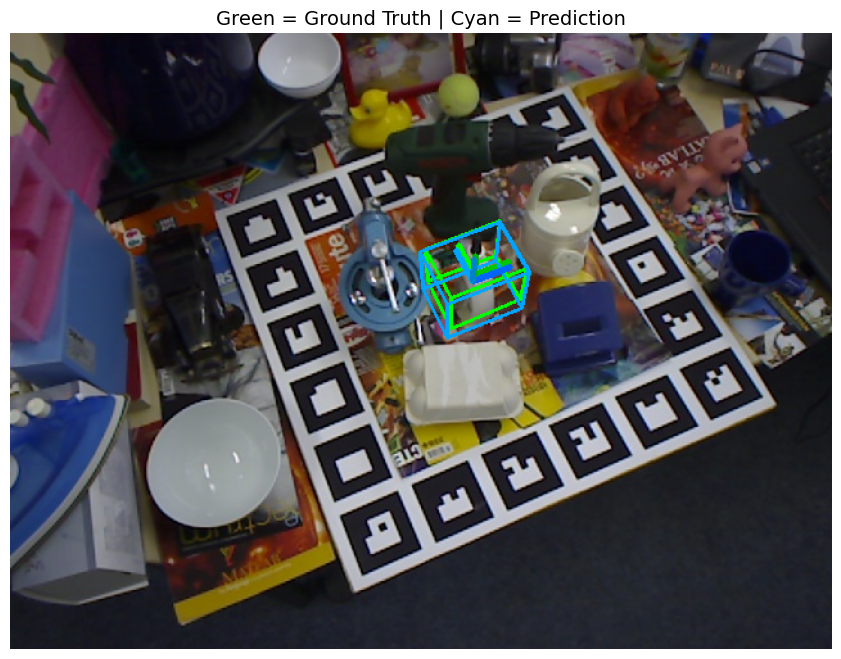

In [17]:
import importlib, baseline_visualize
importlib.reload(baseline_visualize)
from baseline_visualize import visualize_baseline_predictions

visualize_baseline_predictions(
    dataset_root,
    cam_k=cam_k,
    image_path=str(dataset_root / "data" / "11" / "rgb" / "0069.png"),
    yolo_checkpoint= checkpoint_best_yolo_path,
    pose_checkpoint= checkpoint_best_pose_path,
    device=device,
    img_mean=[0.485, 0.456, 0.406],
    img_std=[0.229, 0.224, 0.225]
)

### Testing YOLO + ResNet Pipeline (Baseline)

In [ ]:
import importlib
import baseline_full_pipeline_test
importlib.reload(baseline_full_pipeline_test)

from baseline_full_pipeline_test import evaluate_full_pipeline

pipeline_test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2
)

evaluate_full_pipeline(
    test_dataset=test_dataset,  
    test_loader=pipeline_test_loader,    
    cam_k=cam_k,
    yolo_checkpoint=checkpoint_best_yolo_path,
    pose_checkpoint=checkpoint_best_pose_path,
    device=device
)

Full Pipeline Eval: 100%|██████████| 1580/1580 [03:34<00:00,  7.37it/s]


FULL PIPELINE DIAGNOSTICS:
Total Samples: 1580
✅ Valid Predictions (Box+Class OK): 1579
❌ Discarded (Wrong Class):        0
❌ Discarded (No Detection):       1



,Object Name,#Samples,Accuracy @10% (%),ADD-R Accuracy @10% (%),Rotation Error (deg),Translation Error (cm),ADD / ADD-S (cm),ADD-R (cm)
0,ape,123,1.63,82.11,7.64,13.00,13.05,0.74
1,benchvise,122,12.30,86.07,6.87,11.46,11.60,1.56
2,camera,120,0.83,91.67,6.45,11.65,11.72,0.97
3,can,119,18.49,89.08,6.73,9.05,9.28,1.30
4,cat,118,0.00,95.76,6.54,19.29,19.31,0.83
5,driller,119,2.52,95.80,6.21,13.79,13.86,1.32
6,duck,126,0.00,83.33,6.98,8.71,8.74,0.75
7,eggbox,125,5.60,99.20,4.22,11.37,8.94,0.56
8,glue,122,16.39,99.18,4.35,22.01,18.44,0.56
9,holepuncher,123,0.81,95.93,7.66,16.16,16.23,0.86


## 6D Pose Estimation (Extension - RGB-D Fusion)

### Define Extension Dataset (RGB-D)

In [14]:
from data.CustomDatasetPoseExtension import RGBDDatasetPose

# Split 80% training / 20% testing (come baseline)
train_dataset_ext = RGBDDatasetPose(
    dataset_root=dataset_root,
    split="train",
    train_ratio=0.8,
    seed=42,
    cam_K=cam_k
)
test_dataset_ext = RGBDDatasetPose(
    dataset_root=dataset_root,
    split="test",
    train_ratio=0.8,
    seed=42,
    cam_K=cam_k
)

print(f"Extension - Training samples: {len(train_dataset_ext)} (80%)")
print(f"Extension - Testing samples: {len(test_dataset_ext)} (20%)")
print(f"Note: Test set verrà usato anche per validation durante training")

Extension - Training samples: 12640 (80%)
Extension - Testing samples: 3160 (20%)
Note: Test set verrà usato anche per validation durante training


### Setup Extension Model and Configuration

In [15]:
if EXEC_ENV == "kaggle":
    config_ext = {
        "num_workers": 4,
        "batch_size": 64,         # Più basso per RGB-D (più memoria)
        "num_epochs": 100,
        "lr_rgb_backbone": 1e-6,  # Più basso per RGB backbone (già pretrained)
        "lr_new_components": 1e-4, # Più alto per depth encoder e fusion
        "weight_decay": 1e-4,
        "freeze_rgb_epochs": 10,    # Freeziamo RGB backbone per 5 epoche
        "partial_unfreeze": True
    }
else:
    config_ext = {
        "num_workers": 2,
        "batch_size": 16,          # Più basso per gestire depth su GPU locale
        "num_epochs": 100,
        "lr_rgb_backbone": 1e-6,
        "lr_new_components": 1e-4,
        "weight_decay": 1e-4,
        "freeze_rgb_epochs": 10,
        "partial_unfreeze": True
    }

print(f"Using device: {device}")
print(f"Extension Configuration: {config_ext}")

Using device: cuda
Extension Configuration: {'num_workers': 2, 'batch_size': 16, 'num_epochs': 100, 'lr_rgb_backbone': 1e-06, 'lr_new_components': 0.0001, 'weight_decay': 0.0001, 'freeze_rgb_epochs': 10, 'partial_unfreeze': True}


### Training Extension Model

In [16]:
import importlib
import extension_train
importlib.reload(extension_train)
from extension_train import train as train_extension

train_loader_ext = DataLoader(
    train_dataset_ext,
    batch_size=config_ext["batch_size"],
    shuffle=True,
    num_workers=config_ext["num_workers"],
    pin_memory=True,
    persistent_workers=True
)

# Usiamo test_dataset_ext anche per validation durante training
val_loader_ext = DataLoader(
    test_dataset_ext,
    batch_size=config_ext["batch_size"],
    shuffle=False,
    num_workers=config_ext["num_workers"],
    pin_memory=True,
    persistent_workers=True
)

print(f"Extension Training on {len(train_dataset_ext)} samples (80%)")
print(f"Extension Validating on {len(test_dataset_ext)} samples (20% - same as test)")
print(f"Epochs: {config_ext['num_epochs']}, Batch size: {config_ext['batch_size']}\n")

# Set to None for fresh training, or path to checkpoint to resume
resume_checkpoint_ext = None  # or str(Path("checkpoints") / "best_extension_model.pt")

train_extension(
    train_loader=train_loader_ext,
    val_loader=val_loader_ext,
    cam_k=cam_k,
    checkpoint_dir="checkpoints",
    epochs=config_ext["num_epochs"],
    lr_rgb_backbone=config_ext["lr_rgb_backbone"],
    lr_new_components=config_ext["lr_new_components"],
    weight_decay=config_ext["weight_decay"],
    device=device,
    freeze_rgb_epochs=config_ext["freeze_rgb_epochs"],
    resume_from_checkpoint=resume_checkpoint_ext
)

print("\nExtension Training complete!")

Extension Training on 12640 samples (80%)
Extension Validating on 3160 samples (20% - same as test)
Epochs: 100, Batch size: 16

Mixed Precision (AMP): ENABLED

Epoch 1/100
LR Backbone RGB: 1.00e-05 | LR Heads: 1.00e-04


**Training**: 100%|██████████| 790/790 [06:23<00:00,  2.06it/s]


  Train Loss: 421.5885 (Rot: 23.11°, Trans: 36.50 cm, Proj: 9.23 px)


**Validation**: 100%|██████████| 198/198 [01:30<00:00,  2.18it/s]


  Val Loss: 136.4762 (Rot: 20.28°, Trans: 13.69 cm, Proj: 5.11 px)
✓ Checkpoint salvato: checkpoints\best_fusion_model.pt (Loss: 136.4762)


Epoch 2/100
LR Backbone RGB: 1.00e-05 | LR Heads: 1.00e-04


...

  Train Loss: -7.5785 (Rot: 1.36°, Trans: 3.46 cm, Proj: 1.64 px)


**Validation**: 100%|██████████| 198/198 [01:58<00:00,  1.66it/s]


  Val Loss: -5.7926 (Rot: 0.91°, Trans: 10.57 cm, Proj: 1.80 px)
✓ Checkpoint salvato: checkpoints\best_fusion_model.pt (Loss: -5.7926)


Epoch 62/100
LR Backbone RGB: 1.00e-05 | LR Heads: 1.00e-04


**Training**:  15%|█▍        | 118/790 [01:26<08:10,  1.37it/s]


KeyboardInterrupt: 

In [ ]:
if EXEC_ENV == "kaggle":
    # Crea cartella output per extension model
    output_dir_ext = "/kaggle/working/extension_checkpoint"
    os.makedirs(output_dir_ext, exist_ok=True)

    # Copia il best extension model
    source_ext = "/kaggle/working/6D-pose-estimation/checkpoints/best_extension_model.pt"
    dest_ext = os.path.join(output_dir_ext, "best_extension_model.pt")

    if os.path.exists(source_ext):
        shutil.copy(source_ext, dest_ext)
        size_ext = os.path.getsize(dest_ext) / (1024 * 1024)
        
        print(f"✅ Best extension model saved!")
        print(f"   Location: {dest_ext}")
        print(f"   Size: {size_ext:.2f} MB")
        print(f"\n📥 Download from Output tab: extension_checkpoint/best_extension_model.pt")
    else:
        print(f"❌ Best extension model not found at: {source_ext}")

### Evaluation Extension Model

In [16]:
import importlib
import extension_evaluate
importlib.reload(extension_evaluate)

from extension_evaluate import evaluate_extension

test_loader_ext = DataLoader(
    test_dataset_ext,
    batch_size=config_ext["batch_size"],
    shuffle=False,
    num_workers=config_ext["num_workers"],
    pin_memory=True
)

if EXEC_ENV == "kaggle":
    checkpoint_best_extension_path = Path("/kaggle/input/chekpoint") / "best_fusion_model.pt"
else:
    checkpoint_best_extension_path = Path("checkpoints") / "best_fusion_model.pt"

evaluate_extension(
    dataset_root=dataset_root,
    test_dataset=test_dataset_ext,
    test_loader=test_loader_ext,
    cam_k=cam_k,
    checkpoint_path=checkpoint_best_extension_path,
    device=device,
    save_table=False,
    table_path="./extension_evaluation_results.csv"
)

c:\Users\Davide\OneDrive\Documenti\Universita\Magistrale\Corsi\Advance machine learning\project\6D-pose-estimation\extension_evaluate.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experiment

Evaluating RGB-D Extension...


Test Batch: 100%|██████████| 198/198 [01:28<00:00,  2.25it/s]


,Object Name,#Samples,Accuracy @10% (%),ADD-R Accuracy @10% (%),Rotation Error (deg),Translation Error (cm),ADD / ADD-S (cm),ADD-R (cm)
0,ape,247,2.83,53.85,11.42,11.63,11.72,1.10
1,benchvise,243,9.47,63.79,10.35,9.29,9.72,2.31
2,camera,240,2.50,73.75,8.79,10.53,10.69,1.35
3,can,239,6.28,54.39,11.55,10.54,10.91,2.17
4,cat,236,4.24,70.34,10.52,11.84,11.97,1.34
5,driller,238,6.30,65.97,10.28,9.82,10.16,2.23
6,duck,251,3.19,67.73,9.45,12.30,12.40,1.01
7,eggbox,251,5.98,92.43,7.91,11.02,8.62,0.97
8,glue,244,9.43,90.57,8.00,10.11,8.31,0.99
9,holepuncher,247,1.21,65.18,11.45,11.47,11.63,1.33


### Visualize Extension Predictions

Loading YOLO: checkpoints\best_yolo_model.pt
Loading FusionPoseNet: checkpoints\best_fusion_model.pt


c:\Users\Davide\OneDrive\Documenti\Universita\Magistrale\Corsi\Advance machine learning\project\6D-pose-estimation\extension_visualize.py:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimen


VISUALIZATION: 0069.png

 Object 9 (Class 8)

 GROUND TRUTH:
     Translation: [ 0.0623, -0.0899,  0.9706] m
     Quaternion:  [-0.2071, -0.9571,  0.2007, -0.0279]

 PREDICTION:
     Translation: [ 0.0528, -0.0768,  0.7997] m
     Quaternion:  [ 0.1745,  0.9745, -0.1392,  0.0220]

 ERRORS:
     BBox IoU (2D) by YOLO: 91.45%
     Translation Error: 17.17 cm
       - X error:  -0.95 cm
       - Y error:   1.31 cm
       - Z error (depth): -17.09 cm
     Rotation Error: 8.25°


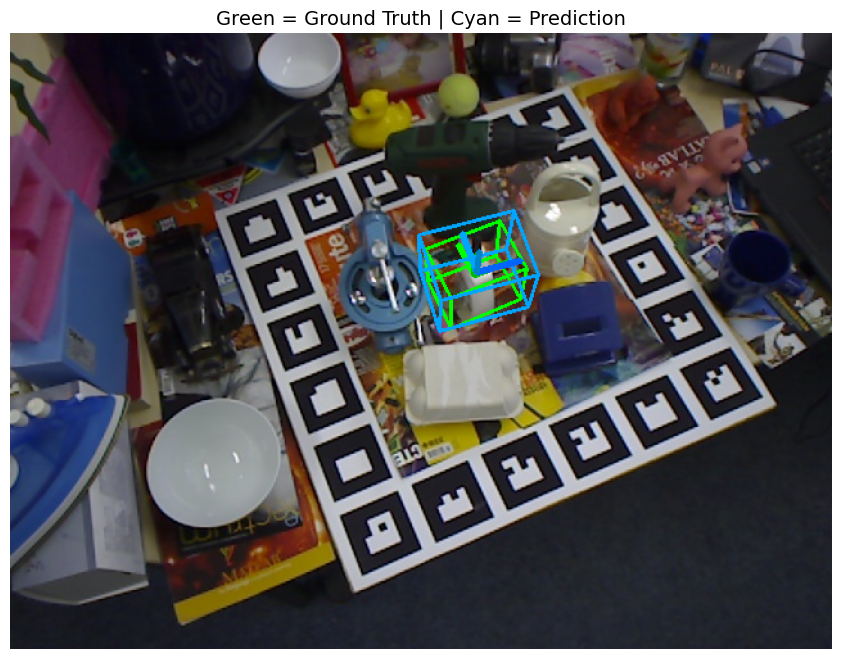

In [17]:
import importlib, extension_visualize
importlib.reload(extension_visualize)
from extension_visualize import visualize_fusion_predictions

visualize_fusion_predictions(
    dataset_root,
    cam_k=cam_k,
    image_path=str(dataset_root / "data" / "11" / "rgb" / "0069.png"),
    yolo_checkpoint=checkpoint_best_yolo_path,
    fusion_checkpoint=checkpoint_best_extension_path,
    device=device,
    img_mean=[0.485, 0.456, 0.406],
    img_std=[0.229, 0.224, 0.225]
)